Group Members: Andrew Mankin, Ryan Safa

So there is no reduced feature set

We are also just going to do a simple cnn

In [60]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import tensorflow as tf
from tqdm import tqdm
import matplotlib.image as img
import cv2
from sklearn.model_selection import train_test_split
tf.keras.backend.clear_session()

In [2]:
data = pd.read_csv(index_col=0, filepath_or_buffer="data.csv")
data.head()

,subject,image_path,image_type,session,label
0,sub-S330013,./positive/sub-S330013/ses-E61063/mod-rx/sub-S...,MONOCHROME2,ses-E61063,True
1,sub-S326512,./positive/sub-S326512/ses-E53169/mod-rx/sub-S...,MONOCHROME2,ses-E53169,True
2,sub-S326512,./positive/sub-S326512/ses-E53169/mod-rx/sub-S...,MONOCHROME2,ses-E53169,True
3,sub-S333838,./positive/sub-S333838/ses-E70937/mod-rx/sub-S...,MONOCHROME2,ses-E70937,True
4,sub-S333838,./positive/sub-S333838/ses-E70937/mod-rx/sub-S...,MONOCHROME2,ses-E70937,True


preprocess all the image paths to matplotlib images

In [3]:
def load_image(path):
    img = cv2.imread(path, cv2.IMREAD_GRAYSCALE)

    if img is None:
        print("Bad image:", path)
        return None

    img = cv2.resize(img, (224, 224))
    img = img.astype("float32") / 255.0
    #img = np.stack([img, img, img], axis=-1)
    return img

In [4]:
images = []
labels = []

with tqdm(total=len(data)) as pbar:
    for path, label in zip(data['image_path'], data["label"]):
        img = load_image(path)
        if img is None:
            continue
        images.append(img)
        labels.append(label)
        pbar.update()

X = np.array(images, dtype=np.float32)
y = np.array(labels, dtype=bool)

  0%|          | 0/166 [00:00<?, ?it/s]

100%|██████████| 166/166 [00:13<00:00, 12.65it/s]


In [5]:
X = np.expand_dims(X, axis=-1)

In [6]:
print("X shape:", X.shape)
print("X dtype:", X.dtype)
print("X min/max:", X.min(), X.max())

print("y shape:", y.shape)
print("y dtype:", y.dtype)
print("labels:", set(y))

X shape: (166, 224, 224, 1)
X dtype: float32
X min/max: 0.0 1.0
y shape: (166,)
y dtype: bool
labels: {np.False_, np.True_}


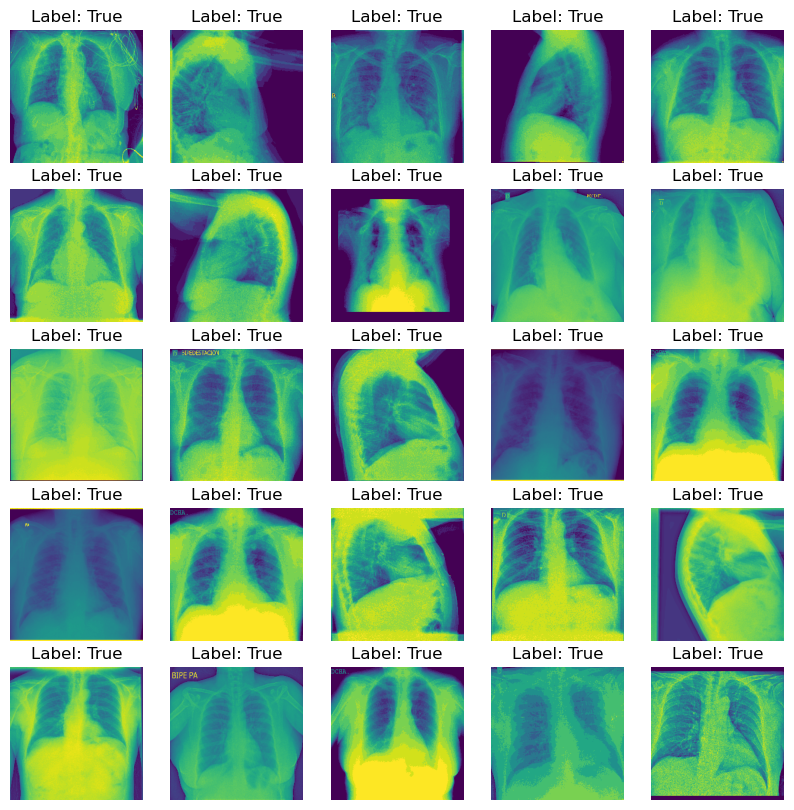

In [7]:
# verify the data
plt.figure(figsize=(10,10))
for i in range(25):
    plt.subplot(5, 5, i+1)
    plt.imshow(X[i])
    plt.title(f"Label: {y[i]}")
    plt.axis('off')
plt.show()

Split the data into train and test

In [8]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

In [9]:
print(X_train.shape)
print(X_test.shape)


(132, 224, 224, 1)
(34, 224, 224, 1)


In [43]:
base_model = tf.keras.applications.EfficientNetB0(
    include_top=False,
    # weights="imagenet",
    input_shape=(224, 224, 3)
)
"""
model = tf.keras.models.Sequential([
    tf.keras.Input(shape=(224, 224, 1)),
    tf.keras.layers.Conv2D(32, (3,3), activation='relu'),
    tf.keras.layers.MaxPooling2D((2,2)),
    tf.keras.layers.Conv2D(64, (3,3), activation='relu'),
    tf.keras.layers.MaxPooling2D((2,2)),
    tf.keras.layers.Conv2D(128, (3,3), activation='relu'),
    tf.keras.layers.MaxPooling2D((2,2)),

    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(64, activation='relu'),
    tf.keras.layers.Dropout(0.4),
    tf.keras.layers.Dense(1, activation='sigmoid')  # binary classification
])
"""

"\nmodel = tf.keras.models.Sequential([\n    tf.keras.Input(shape=(224, 224, 1)),\n    tf.keras.layers.Conv2D(32, (3,3), activation='relu'),\n    tf.keras.layers.MaxPooling2D((2,2)),\n    tf.keras.layers.Conv2D(64, (3,3), activation='relu'),\n    tf.keras.layers.MaxPooling2D((2,2)),\n    tf.keras.layers.Conv2D(128, (3,3), activation='relu'),\n    tf.keras.layers.MaxPooling2D((2,2)),\n\n    tf.keras.layers.Flatten(),\n    tf.keras.layers.Dense(64, activation='relu'),\n    tf.keras.layers.Dropout(0.4),\n    tf.keras.layers.Dense(1, activation='sigmoid')  # binary classification\n])\n"

In [62]:
inputs = tf.keras.Input(shape=(224, 224, 1))
x = tf.keras.layers.Lambda(lambda x: tf.image.grayscale_to_rgb(x))(inputs)
# EfficientNet backbone
x = base_model(x, training=False)

# classification head
x = tf.keras.layers.GlobalAveragePooling2D()(x)
x = tf.keras.layers.Dropout(0.5)(x)
outputs = tf.keras.layers.Dense(1, activation="sigmoid")(x)

model = tf.keras.Model(inputs, outputs)

In [68]:
model.compile(
    optimizer=tf.keras.optimizers.AdamW(1e-3),
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

In [69]:
history = model.fit(
    X_train, y_train,
    validation_data=(X_test, y_test),
    epochs=10,
    batch_size=32,
)

Epoch 1/10
5/5 ━━━━━━━━━━━━━━━━━━━━ 24s 1s/step - accuracy: 0.9924 - loss: 0.0690 - val_accuracy: 0.4118 - val_loss: 0.6911
Epoch 2/10
5/5 ━━━━━━━━━━━━━━━━━━━━ 7s 1s/step - accuracy: 0.9545 - loss: 0.1961 - val_accuracy: 0.4412 - val_loss: 0.8108
Epoch 3/10
5/5 ━━━━━━━━━━━━━━━━━━━━ 7s 1s/step - accuracy: 0.9848 - loss: 0.0424 - val_accuracy: 0.4118 - val_loss: 0.7095
Epoch 4/10
5/5 ━━━━━━━━━━━━━━━━━━━━ 7s 1s/step - accuracy: 0.9773 - loss: 0.0684 - val_accuracy: 0.4412 - val_loss: 3.7798
Epoch 5/10
5/5 ━━━━━━━━━━━━━━━━━━━━ 7s 1s/step - accuracy: 0.9773 - loss: 0.0568 - val_accuracy: 0.4412 - val_loss: 3.4872
Epoch 6/10
5/5 ━━━━━━━━━━━━━━━━━━━━ 7s 1s/step - accuracy: 0.9621 - loss: 0.0771 - val_accuracy: 0.4412 - val_loss: 2.1571
Epoch 7/10
5/5 ━━━━━━━━━━━━━━━━━━━━ 7s 1s/step - accuracy: 0.9697 - loss: 0.1023 - val_accuracy: 0.4118 - val_loss: 1.3215
Epoch 8/10
5/5 ━━━━━━━━━━━━━━━━━━━━ 8s 1s/step - accuracy: 0.9773 - loss: 0.1388 - val_accuracy: 0.4118 - val_loss: 0.9808
Epoch 9/10
5/5 

2/2 - 0s - 137ms/step - accuracy: 0.5588 - loss: 1.3403


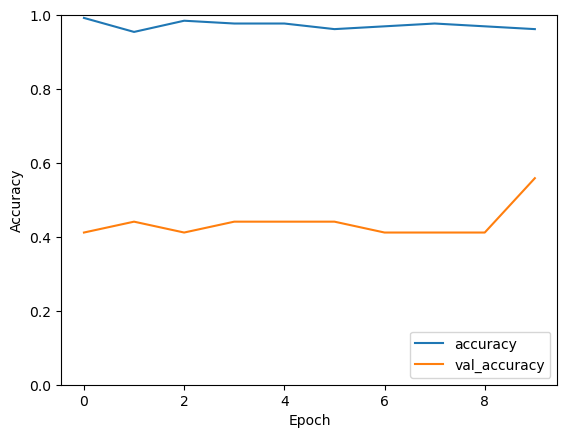

In [70]:
plt.plot(history.history['accuracy'], label='accuracy')
plt.plot(history.history['val_accuracy'], label = 'val_accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.ylim([0, 1])
plt.legend(loc='lower right')

test_loss, test_acc = model.evaluate(X_test,  y_test, verbose=2)

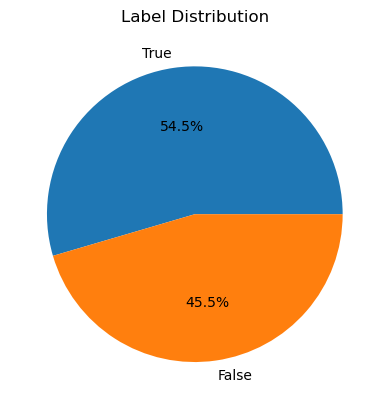

In [31]:

counts = pd.Series(y_train).value_counts()

plt.pie(counts, labels=counts.index, autopct='%1.1f%%')
plt.title("Label Distribution")
plt.show()